# Projeto 03 — Alerta Vermelho: Crise Ambiental Misteriosa
**MBA em Ciência de Dados — UNIFOR** | **Disciplina:** Programação para Ciência de Dados

## Capítulo 1: Reconhecimento da Cena
Nesta etapa inicial, vamos configurar nosso ambiente, carregar os dados fornecidos pela Secretaria de Meio Ambiente e fazer a primeira inspeção das evidências. Nosso objetivo imediato é entender o volume de dados, os tipos de variáveis e mapear inconsistências crônicas, como os valores negativos de NO2 relatados no briefing da operação.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurações visuais padronizadas para o relatório
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
warnings.filterwarnings('ignore')

In [2]:
# Carregando as evidências
df_ar = pd.read_csv('../data/projeto_03_qualidade_ar.csv')
df_internacoes = pd.read_csv('../data/projeto_03_internacoes_respiratorias.csv')
df_industrias = pd.read_csv('../data/projeto_03_cadastro_industrias.csv')

# Visualizando as primeiras linhas e a estrutura do dataset de Qualidade do Ar
display(df_ar.head())

print("\n--- Informações Estruturais (Qualidade do Ar) ---")
df_ar.info()

print("\n--- Resumo Estatístico (Buscando anomalias como NO2 negativo) ---")
display(df_ar.describe())

,data,hora,estacao,tipo_zona,mp25_ugm3,mp10_ugm3,o3_ugm3,no2_ugm3,so2_ugm3,temperatura_c,umidade_relativa_pct
0,2023-01-01,0,Centro,urbana,25.9,49.4,16.8,22.5,8.7,24.1,73.8
1,2023-01-01,6,Centro,urbana,NaN,30.8,24.1,30.4,14.6,27.6,82.3
2,2023-01-01,12,Centro,urbana,25.7,32.9,45.4,23.7,7.0,26.8,83.9
3,2023-01-01,18,Centro,urbana,27.2,41.5,60.7,28.6,11.9,25.9,81.8
4,2023-01-01,22,Centro,urbana,5.7,36.1,50.9,20.3,7.2,26.8,86.1



--- Informações Estruturais (Qualidade do Ar) ---
<class 'pandas.DataFrame'>
RangeIndex: 29200 entries, 0 to 29199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   data                  29200 non-null  str    
 1   hora                  29200 non-null  int64  
 2   estacao               29200 non-null  str    
 3   tipo_zona             29200 non-null  str    
 4   mp25_ugm3             28055 non-null  float64
 5   mp10_ugm3             28044 non-null  float64
 6   o3_ugm3               28054 non-null  float64
 7   no2_ugm3              29200 non-null  float64
 8   so2_ugm3              29200 non-null  float64
 9   temperatura_c         29200 non-null  float64
 10  umidade_relativa_pct  29200 non-null  float64
dtypes: float64(7), int64(1), str(3)
memory usage: 2.5 MB

--- Resumo Estatístico (Buscando anomalias como NO2 negativo) ---


,hora,mp25_ugm3,mp10_ugm3,o3_ugm3,no2_ugm3,so2_ugm3,temperatura_c,umidade_relativa_pct
count,29200.000000,28055.000000,28044.000000,28054.000000,29200.000000,29200.000000,29200.000000,29200.000000
mean,11.600000,27.839761,48.202753,38.941616,29.119610,12.993240,28.296134,69.418144
std,7.939909,20.019597,30.845629,16.391143,15.151941,11.422089,3.077217,15.966003
min,0.000000,1.000000,2.000000,0.000000,-77.200000,0.000000,17.200000,20.000000
25%,6.000000,14.200000,25.700000,27.700000,19.400000,7.000000,26.100000,57.300000
50%,12.000000,21.600000,38.300000,38.700000,27.500000,10.700000,28.200000,68.800000
75%,18.000000,36.200000,64.600000,50.100000,36.400000,15.400000,30.400000,82.900000
max,22.000000,181.700000,250.800000,103.000000,126.500000,95.600000,41.100000,100.000000


## Capítulo 2: Tratamento das Evidências e Limpeza da Cena

A inspeção inicial revelou ruídos nos equipamentos de medição. Identificamos registros fisicamente impossíveis (concentrações negativas de Dióxido de Nitrogênio) e lacunas nas leituras de material particulado e ozônio, indicando possíveis falhas temporais nos sensores das estações.

Para garantir a integridade da nossa investigação sem perder dados valiosos, nossa estratégia de limpeza será:
1. **Isolar o erro de medição:** Substituir valores negativos de NO2 por nulos (`NaN`).
2. **Reconstruir a linha do tempo:** Converter todas as colunas de data para o formato `datetime` nativo do Pandas.
3. **Preencher as lacunas (Imputação):** Como a poluição do ar é um processo contínuo no tempo, utilizaremos a **interpolação linear** agrupada por estação. Isso estima os valores ausentes com base nas medições imediatamente anteriores e posteriores, oferecendo a aproximação mais realista da realidade.

In [3]:
# 1. Tratamento da anomalia do NO2
qtd_erros_no2 = (df_ar['no2_ugm3'] < 0).sum()
print(f"Encontrados e isolados {qtd_erros_no2} registros com erro de NO2 negativo.")

# Substituindo os valores negativos por NaN (Nulo)
df_ar.loc[df_ar['no2_ugm3'] < 0, 'no2_ugm3'] = np.nan

# 2. Conversão de Tipos (Datas)
df_ar['data'] = pd.to_datetime(df_ar['data'])
df_internacoes['data_internacao'] = pd.to_datetime(df_internacoes['data_internacao'])

# O errors='coerce' transforma datas inválidas no cadastro de indústrias em NaT (Not a Time)
if 'data_ultima_fiscalizacao' in df_industrias.columns:
    df_industrias['data_ultima_fiscalizacao'] = pd.to_datetime(df_industrias['data_ultima_fiscalizacao'], errors='coerce')

# 3. Ordenação temporal e Interpolação
# Precisamos garantir que os dados estão em ordem cronológica antes de interpolar
df_ar = df_ar.sort_values(by=['estacao', 'data', 'hora']).reset_index(drop=True)

# Selecionando apenas as colunas de poluentes para a imputação
colunas_poluentes = ['mp25_ugm3', 'mp10_ugm3', 'o3_ugm3', 'no2_ugm3']

# Aplicando a interpolação linear agrupada por estação
df_ar[colunas_poluentes] = df_ar.groupby('estacao')[colunas_poluentes].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

# Verificação pós-limpeza
print("\n--- Auditoria de Nulos após Tratamento ---")
print(df_ar.isna().sum())

Encontrados e isolados 19 registros com erro de NO2 negativo.

--- Auditoria de Nulos após Tratamento ---
data                    0
hora                    0
estacao                 0
tipo_zona               0
mp25_ugm3               0
mp10_ugm3               0
o3_ugm3                 0
no2_ugm3                0
so2_ugm3                0
temperatura_c           0
umidade_relativa_pct    0
dtype: int64


## Capítulo 3: Cruzamento de Evidências e a Caçada ao Suspeito

Com os dados limpos e cronologicamente alinhados, iniciamos a fase investigativa guiada por três hipóteses principais:
1. **A Anomalia Noturna:** Analisar o comportamento dos gases tóxicos (SO2 e NO2) durante a noite e madrugada (22h e 0h).
2. **O Epicentro (Jurema):** Isolar os dados de saúde pública e do setor industrial focando no bairro Jurema, área de interesse da Secretaria de Meio Ambiente.
3. **Auditoria Regulatória:** Checar a validade das licenças ambientais e confrontar o horário de operação declarado com os picos reais de poluição.

 PANORAMA GERAL: MÉDIA DE 24 HORAS (Todos os Poluentes)
Legenda: (*) Bairro possui indústrias na nossa base de dados.



,mp25_ugm3,mp10_ugm3,no2_ugm3,so2_ugm3,Total_Poluentes
estacao,,,,,
Jurema *,58.97,96.27,48.71,31.65,235.59
Porto *,39.02,68.69,31.69,16.00,155.40
Distrito Industrial *,39.04,68.84,31.27,15.95,155.09
Centro,24.50,43.49,24.17,8.06,100.22
Aldeota,16.73,29.47,24.59,7.99,78.78
Maraponga *,16.62,29.61,24.37,8.13,78.73
Messejana *,16.74,29.41,24.38,8.08,78.60
Parque do Cocó,11.14,19.66,24.07,8.10,62.98


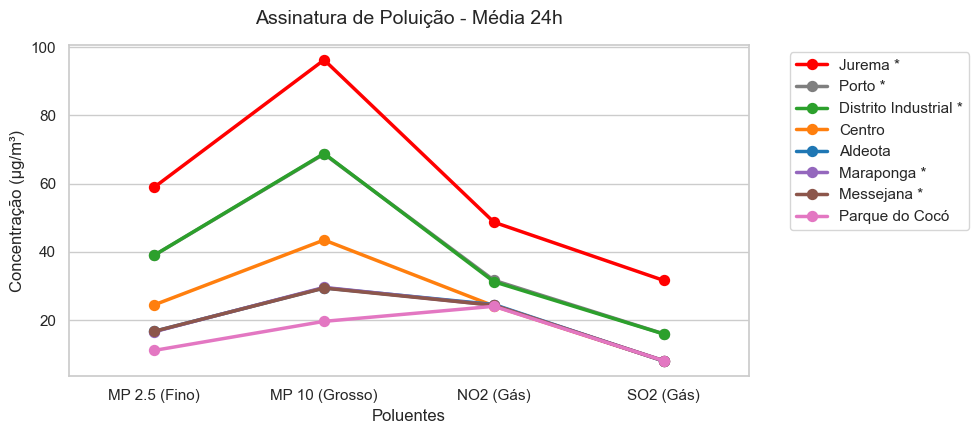

--- Desvio da Média Geral (24h) (Relativo) ---
*(Valores em %, indicam o quanto a estação está acima/abaixo da média da cidade)*


,mp25_ugm3,mp10_ugm3,no2_ugm3,so2_ugm3
estacao,,,,
Jurema *,+111.76%,+99.81%,+67.07%,+143.56%
Porto *,+40.13%,+42.57%,+8.70%,+23.14%
Distrito Industrial *,+40.21%,+42.88%,+7.24%,+22.72%
Centro,-12.03%,-9.73%,-17.10%,-37.99%
Aldeota,-39.91%,-38.83%,-15.65%,-38.51%
Maraponga *,-40.32%,-38.54%,-16.43%,-37.39%
Messejana *,-39.87%,-38.97%,-16.38%,-37.85%
Parque do Cocó,-59.98%,-59.18%,-17.44%,-37.68%



 INVESTIGAÇÃO DE POLUENTES: DIURNO (6h, 12h, 18h)
--- Material Particulado (Poeira/Fuligem) - Média Diurna ---


,mp25_ugm3,mp10_ugm3
estacao,,
Jurema *,43.82,76.06
Porto *,42.97,75.52
Distrito Industrial *,42.71,75.38
Centro,26.99,47.61
Aldeota,18.42,32.44
Messejana *,18.34,32.37
Maraponga *,18.29,32.43
Parque do Cocó,12.24,21.58


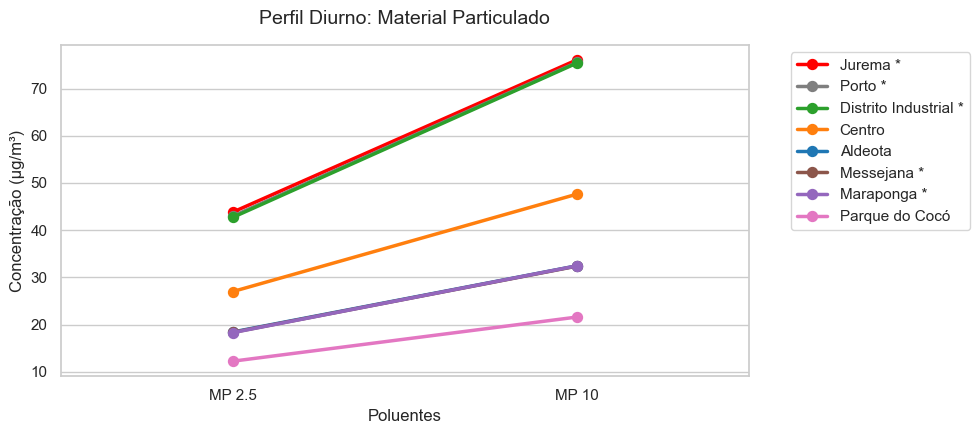

--- Desvio da Média Diurna (Particulados) (Relativo) ---
*(Valores em %, indicam o quanto a estação está acima/abaixo da média da cidade)*


,mp25_ugm3,mp10_ugm3
estacao,,
Jurema *,+56.66%,+54.68%
Porto *,+53.60%,+53.58%
Distrito Industrial *,+52.69%,+53.28%
Centro,-3.50%,-3.17%
Aldeota,-34.14%,-34.04%
Messejana *,-34.44%,-34.18%
Maraponga *,-34.62%,-34.05%
Parque do Cocó,-56.26%,-56.11%



--- Gases Tóxicos Industriais (Combustão) - Média Diurna ---


,no2_ugm3,so2_ugm3
estacao,,
Distrito Industrial *,34.47,16.07
Porto *,34.85,15.97
Jurema *,34.48,15.80
Messejana *,26.81,8.11
Maraponga *,26.74,8.07
Parque do Cocó,26.63,8.05
Centro,26.72,7.91
Aldeota,27.22,7.89


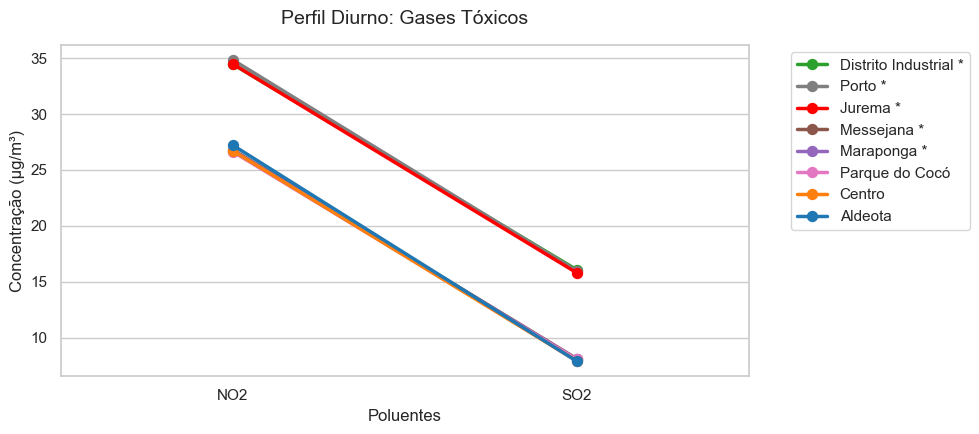

--- Desvio da Média Diurna (Gases Tóxicos) (Relativo) ---
*(Valores em %, indicam o quanto a estação está acima/abaixo da média da cidade)*


,no2_ugm3,so2_ugm3
estacao,,
Distrito Industrial *,+15.89%,+46.33%
Porto *,+17.19%,+45.39%
Jurema *,+15.94%,+43.83%
Messejana *,-9.86%,-26.15%
Maraponga *,-10.09%,-26.54%
Parque do Cocó,-10.44%,-26.75%
Centro,-10.16%,-27.98%
Aldeota,-8.48%,-28.13%



 INVESTIGAÇÃO DE POLUENTES: NOTURNO (22h, 0h)
--- Material Particulado (Poeira/Fuligem) - Média Noturna ---


,mp25_ugm3,mp10_ugm3
estacao,,
Jurema *,81.68,126.58
Distrito Industrial *,33.54,59.03
Porto *,33.10,58.44
Centro,20.75,37.31
Messejana *,14.35,24.96
Aldeota,14.19,25.02
Maraponga *,14.11,25.39
Parque do Cocó,9.50,16.79


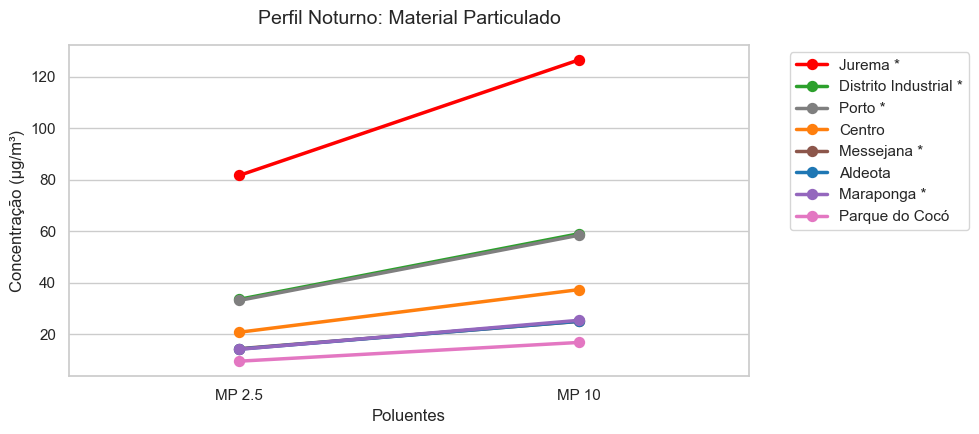

--- Desvio da Média Noturna (Particulados) (Relativo) ---
*(Valores em %, indicam o quanto a estação está acima/abaixo da média da cidade)*


,mp25_ugm3,mp10_ugm3
estacao,,
Jurema *,+195.37%,+171.11%
Distrito Industrial *,+21.27%,+26.43%
Porto *,+19.69%,+25.16%
Centro,-24.97%,-20.08%
Messejana *,-48.11%,-46.54%
Aldeota,-48.67%,-46.41%
Maraponga *,-48.96%,-45.62%
Parque do Cocó,-65.63%,-64.05%



--- Gases Tóxicos Industriais (Combustão) - Média Noturna ---


,no2_ugm3,so2_ugm3
estacao,,
Jurema *,70.05,55.41
Porto *,26.95,16.04
Distrito Industrial *,26.47,15.75
Centro,20.34,8.27
Maraponga *,20.81,8.23
Parque do Cocó,20.23,8.17
Aldeota,20.65,8.13
Messejana *,20.73,8.02


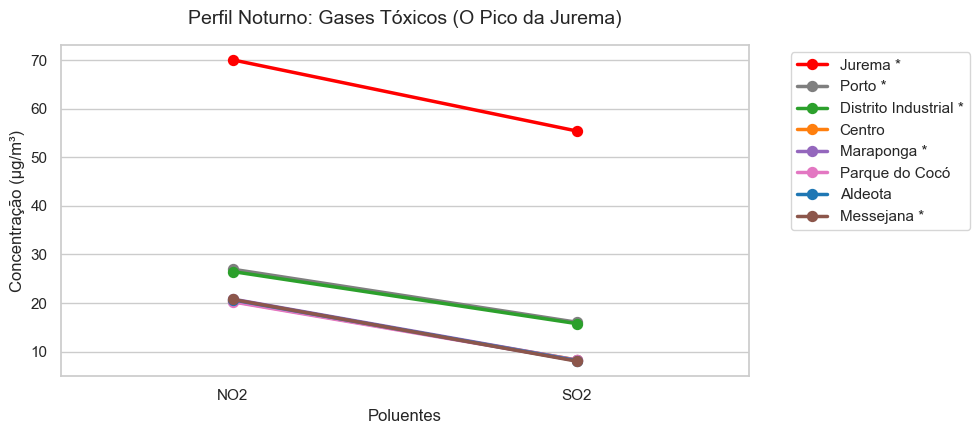

--- Desvio da Média Noturna (Gases Tóxicos) (Relativo) ---
*(Valores em %, indicam o quanto a estação está acima/abaixo da média da cidade)*


,no2_ugm3,so2_ugm3
estacao,,
Jurema *,+147.72%,+246.21%
Porto *,-4.70%,+0.24%
Distrito Industrial *,-6.41%,-1.58%
Centro,-28.07%,-48.30%
Maraponga *,-26.43%,-48.57%
Parque do Cocó,-28.47%,-48.93%
Aldeota,-26.97%,-49.19%
Messejana *,-26.68%,-49.89%



 AUDITORIA INDUSTRIAL: O FOCO NA JUREMA

--- Ficha Completa das Indústrias Localizadas na Jurema ---


,industria_id,nome,bairro,tipo_atividade,porte,licenca_ambiental,data_ultima_fiscalizacao,horario_operacao_declarado,emissoes_declaradas_ton_ano
0,IND-001,QuimNorte Ltda,Jurema,Química Industrial,Grande,Vencida,2021-08-15,08:00-18:00,12.5
3,IND-004,PlastCE Indústria,Jurema,Plásticos,Médio,Vigente,2023-11-05,08:00-18:00,3.2


In [15]:
# ==============================================================================
# 1. SETUP VISUAL E IDENTIDADE DO RELATÓRIO
# ==============================================================================

# Identificando dinamicamente os bairros que possuem cadastro industrial
bairros_com_industria = df_industrias['bairro'].unique()

# Função auxiliar para marcar as estações com asterisco
def marcar_estacao(nome_estacao):
    return f"{nome_estacao} *" if nome_estacao in bairros_com_industria else nome_estacao

# Criando a paleta de cores FIXA já com os asteriscos nos nomes
estacoes_originais = df_ar['estacao'].unique()
paleta = sns.color_palette("tab10", len(estacoes_originais))
cores_estacoes = {marcar_estacao(est): cor for est, cor in zip(estacoes_originais, paleta)}

# Forçando o destaque vermelho para a Jurema (A suspeita principal)
cores_estacoes[marcar_estacao('Jurema')] = 'red'

# Função para padronizar e plotar os gráficos
def plotar_perfil(df_tabela, titulo, labels_x):
    if 'Total_Poluentes' in df_tabela.columns:
        df_plot = df_tabela.drop(columns=['Total_Poluentes'])
    else:
        df_plot = df_tabela.copy()
        
    df_melt = df_plot.reset_index().melt(id_vars='estacao', var_name='Poluente', value_name='Concentração (µg/m³)')
    
    plt.figure(figsize=(10, 4.5))
    sns.pointplot(
        data=df_melt, x='Poluente', y='Concentração (µg/m³)', 
        hue='estacao', palette=cores_estacoes, markers='o', linewidth=2.5
    )
    plt.title(titulo, fontsize=14, pad=15)
    plt.xlabel('Poluentes', fontsize=12)
    plt.ylabel('Concentração (µg/m³)', fontsize=12)
    plt.xticks(ticks=range(len(labels_x)), labels=labels_x)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Função para calcular e exibir a tabela de desvios percentuais em relação à média
def mostrar_desvios(df_tabela, titulo_desvio):
    if 'Total_Poluentes' in df_tabela.columns:
        df_calc = df_tabela.drop(columns=['Total_Poluentes'])
    else:
        df_calc = df_tabela.copy()
        
    # Calcula a média geral de cada coluna (a média da cidade inteira)
    media_cidade = df_calc.mean()
    
    # Calcula o desvio relativo (percentual): ((Valor - Média) / Média) * 100
    df_desvio_pct = ((df_calc - media_cidade) / media_cidade) * 100
    
    print(f"--- {titulo_desvio} (Relativo) ---")
    print("*(Valores em %, indicam o quanto a estação está acima/abaixo da média da cidade)*")
    
    # Formatando para exibir com o sinal e o símbolo de %
    df_formatado = df_desvio_pct.apply(lambda col: col.map("{:+.2f}%".format))
    display(df_formatado)

# ==============================================================================
# 2. PANORAMA GERAL (24 HORAS)
# ==============================================================================
print("="*60)
print(" PANORAMA GERAL: MÉDIA DE 24 HORAS (Todos os Poluentes)")
print("="*60)
print("Legenda: (*) Bairro possui indústrias na nossa base de dados.\n")

panorama_geral = df_ar.groupby('estacao')[['mp25_ugm3', 'mp10_ugm3', 'no2_ugm3', 'so2_ugm3']].mean()
panorama_geral['Total_Poluentes'] = panorama_geral.sum(axis=1)
panorama_geral = panorama_geral.sort_values(by='Total_Poluentes', ascending=False)
panorama_geral.index = panorama_geral.index.map(marcar_estacao)

display(panorama_geral.round(2))
plotar_perfil(
    panorama_geral, 
    'Assinatura de Poluição - Média 24h', 
    ['MP 2.5 (Fino)', 'MP 10 (Grosso)', 'NO2 (Gás)', 'SO2 (Gás)']
)
mostrar_desvios(panorama_geral, 'Desvio da Média Geral (24h)')

# Separando os dataframes por período para a análise detalhada
diurno_df = df_ar[df_ar['hora'].isin([6, 12, 18])]
noturno_df = df_ar[df_ar['hora'].isin([22, 0])]

# ==============================================================================
# 3. INVESTIGAÇÃO DIURNA (6h, 12h, 18h)
# ==============================================================================
print("\n" + "="*60)
print(" INVESTIGAÇÃO DE POLUENTES: DIURNO (6h, 12h, 18h)")
print("="*60)

# --- Material Particulado (Diurno) ---
poeira_diurna = diurno_df.groupby('estacao')[['mp25_ugm3', 'mp10_ugm3']].mean().sort_values(by='mp25_ugm3', ascending=False)
poeira_diurna.index = poeira_diurna.index.map(marcar_estacao)
print("--- Material Particulado (Poeira/Fuligem) - Média Diurna ---")
display(poeira_diurna.round(2))
plotar_perfil(poeira_diurna, 'Perfil Diurno: Material Particulado', ['MP 2.5', 'MP 10'])
mostrar_desvios(poeira_diurna, 'Desvio da Média Diurna (Particulados)')

# --- Gases Industriais (Diurno) ---
gases_diurnos = diurno_df.groupby('estacao')[['no2_ugm3', 'so2_ugm3']].mean().sort_values(by='so2_ugm3', ascending=False)
gases_diurnos.index = gases_diurnos.index.map(marcar_estacao)
print("\n--- Gases Tóxicos Industriais (Combustão) - Média Diurna ---")
display(gases_diurnos.round(2))
plotar_perfil(gases_diurnos, 'Perfil Diurno: Gases Tóxicos', ['NO2', 'SO2'])
mostrar_desvios(gases_diurnos, 'Desvio da Média Diurna (Gases Tóxicos)')

# ==============================================================================
# 4. INVESTIGAÇÃO NOTURNA (22h, 0h) - A HORA DO CRIME
# ==============================================================================
print("\n" + "="*60)
print(" INVESTIGAÇÃO DE POLUENTES: NOTURNO (22h, 0h)")
print("="*60)

# --- Material Particulado (Noturno) ---
poeira_noturna = noturno_df.groupby('estacao')[['mp25_ugm3', 'mp10_ugm3']].mean().sort_values(by='mp25_ugm3', ascending=False)
poeira_noturna.index = poeira_noturna.index.map(marcar_estacao)
print("--- Material Particulado (Poeira/Fuligem) - Média Noturna ---")
display(poeira_noturna.round(2))
plotar_perfil(poeira_noturna, 'Perfil Noturno: Material Particulado', ['MP 2.5', 'MP 10'])
mostrar_desvios(poeira_noturna, 'Desvio da Média Noturna (Particulados)')

# --- Gases Industriais (Noturno) ---
gases_noturnos = noturno_df.groupby('estacao')[['no2_ugm3', 'so2_ugm3']].mean().sort_values(by='so2_ugm3', ascending=False)
gases_noturnos.index = gases_noturnos.index.map(marcar_estacao)
print("\n--- Gases Tóxicos Industriais (Combustão) - Média Noturna ---")
display(gases_noturnos.round(2))
plotar_perfil(gases_noturnos, 'Perfil Noturno: Gases Tóxicos (O Pico da Jurema)', ['NO2', 'SO2'])
mostrar_desvios(gases_noturnos, 'Desvio da Média Noturna (Gases Tóxicos)')

# ==============================================================================
# 5. AUDITORIA INDUSTRIAL: O FOCO NA JUREMA
# ==============================================================================
print("\n" + "="*60)
print(" AUDITORIA INDUSTRIAL: O FOCO NA JUREMA")
print("="*60)

industrias_jurema = df_industrias[df_industrias['bairro'] == 'Jurema']
print("\n--- Ficha Completa das Indústrias Localizadas na Jurema ---")
display(industrias_jurema)

In [6]:
# 4. A Prova do Crime e Auditoria de Bairros

# Verificando quais bairros realmente possuem indústrias cadastradas
bairros_cadastrados = df_industrias['bairro'].unique()
print("--- Auditoria de Bairros no Cadastro Industrial ---")
print(f"Nossa base de dados tem o cadastro desses bairros: {', '.join(bairros_cadastrados)}\n")

# Criamos uma regra: 6h, 12h e 18h = Comercial | 22h e 0h = Noturno/Madrugada
df_ar['periodo_dia'] = df_ar['hora'].apply(lambda x: '1_Comercial (6h-18h)' if x in [6, 12, 18] else '2_Noturno (22h-0h)')

# Criamos uma tabela dinâmica calculando a média de SO2 por estação e período
prova_noturna = pd.pivot_table(
    df_ar, 
    values='so2_ugm3', 
    index='estacao', 
    columns='periodo_dia', 
    aggfunc='mean'
)

# Calculamos a variação percentual: quanto a poluição aumenta ou cai à noite?
prova_noturna['Variacao_Noturna (%)'] = ((prova_noturna['2_Noturno (22h-0h)'] / prova_noturna['1_Comercial (6h-18h)']) - 1) * 100

print("--- Auditoria de Emissões: Variação de SO2 (Dia vs. Noite) ---")
display(prova_noturna.sort_values(by='Variacao_Noturna (%)', ascending=False).round(2))

--- Auditoria de Bairros no Cadastro Industrial ---
Nossa base de dados tem o cadastro desses bairros: Jurema, Distrito Industrial, Porto, Maraponga, Messejana

--- Auditoria de Emissões: Variação de SO2 (Dia vs. Noite) ---


periodo_dia,1_Comercial (6h-18h),2_Noturno (22h-0h),Variacao_Noturna (%)
estacao,,,
Jurema,15.80,55.41,250.73
Centro,7.91,8.27,4.60
Aldeota,7.89,8.13,3.01
Maraponga,8.07,8.23,2.01
Parque do Cocó,8.05,8.17,1.59
Porto,15.97,16.04,0.46
Messejana,8.11,8.02,-1.13
Distrito Industrial,16.07,15.75,-1.99
